# Numerisk dobbelt- og trippelintegrasjon med triangulering: Delaunay

Denne notebooken er en oppfølging til **Øving 1, oppgave 17**, der dere deler opp integrasjonsområdet i noen få, håndplukkede trekanter og summerer $f\cdot dA$ over dem. Her repeterer vi kort den ideen, og bygger den så videre ut: `scipy.spatial.Delaunay` kan lage trianguleringen automatisk fra en liste med punkter, slik at vi enkelt kan bruke mange flere trekanter og få en mye bedre tilnærming.

Til slutt tar vi steget opp i **3 dimensjoner**: samme idé -- del opp i små biter, evaluer $f$ i tyngdepunktet til hver bit, og summer -- fungerer nøyaktig like godt når vi bytter ut trekanter med **tetraedre** (firkantflater blir til "firehjørningsklosser"), og $\iint f\,dA$ blir til $\iiint f\,dV$.


## Repetisjon: å integrere ved å summere over trekanter

Vi vil tilnærme
$$\iint_D f(x,y)\, dA$$
ved å dele $D$ opp i $N$ trekanter med hjørner $p_i,q_i,r_i$, og bruke at
$$\iint_D f\, dA \approx \sum_{i=1}^N f(x_i,y_i)\, dA_i,$$
der $(x_i,y_i)=\tfrac13(p_i+q_i+r_i)$ er tyngdepunktet til trekant $i$, og arealet er
$$dA_i = \tfrac12\,\bigl|\det(u_i\ v_i)\bigr|, \qquad u_i = q_i-p_i,\ \ v_i = r_i-p_i.$$

### Eksempel med håndplukkede trekanter

Som i oppgave 17 lager vi en liste med punkter `pts`, og en liste `triangles` som sier hvilke tre punkter (indekser i `pts`) som utgjør hjørnene i hver trekant. Her deler vi rektangelet $[0,2]\times[0,1]$ opp i $4$ trekanter, og integrerer $f(x,y)=x^2+y$ over det. Vi visualiserer også hvor tyngdepunktene til trekantene ligger -- det er der vi evaluerer $f$.

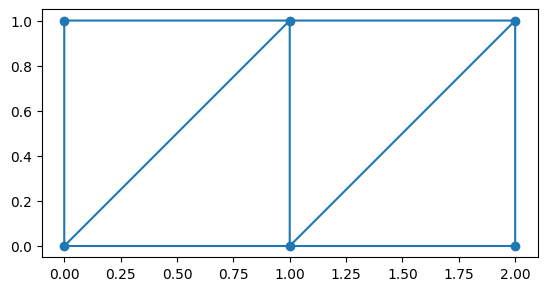

In [1]:
%matplotlib inline
from matplotlib import pyplot as plt
import numpy as np

pts = np.array([[0,0],[1,0],[2,0],[0,1],[1,1],[2,1]])        # liste med punkter (x,y) i planet
triangles = np.array([[0,1,4],[0,4,3],[1,2,5],[1,5,4]])      # hvilke punkter i pts (indekser) som danner hver trekant

plt.triplot(pts[:,0], pts[:,1], triangles)   # tegner selve trekantene
plt.scatter(pts[:,0], pts[:,1])              # tegner punktene som små markører
plt.gca().set_aspect('equal')                # samme skala på x- og y-aksen, så trekantene ser riktige ut
plt.show()

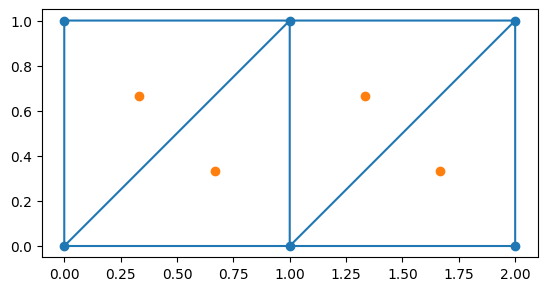

Tilnærmet svar: 3.5555555555555554
Tyngdepunkter:
 [[0.66666667 0.33333333]
 [0.33333333 0.66666667]
 [1.66666667 0.33333333]
 [1.33333333 0.66666667]]
Trekant-arealer: [0.5 0.5 0.5 0.5]


In [2]:
p = pts[triangles[:,0]]   # array med første hjørne i hver trekant
q = pts[triangles[:,1]]   # array med andre hjørne i hver trekant
r = pts[triangles[:,2]]   # array med tredje hjørne i hver trekant
n = len(p)                # antall trekanter -- trengs når vi skal reshape senere

avg = 1/3 * (p + q + r)   # tyngdepunktet (massesenteret) til hver trekant
x = avg[:,0]
y = avg[:,1]
f = x**2 + y              # funksjonen f, evaluert i tyngdepunktene

# Plotting: trekantene, hjørnepunktene, og tyngdepunktene der vi evaluerer f
plt.triplot(pts[:,0], pts[:,1], triangles)   # tegner trekantene
plt.scatter(pts[:,0], pts[:,1])              # tegner hjørnepunktene
plt.scatter(x, y)                            # tegner tyngdepunktene
plt.gca().set_aspect('equal')
plt.show()

# Vektorer som spenner ut hver trekant, med utgangspunkt i hjørnet p
u = q - p
v = r - p

# Setter sammen u og v som kolonner i en 2x2-matrise, én per trekant
Muv = np.column_stack((u, v)).reshape(n, 2, 2)   # (n,2,2) -- en array av 2x2-matriser
dA = np.abs(1/2 * np.linalg.det(Muv))            # arealet til hver trekant, via determinanten

svar = np.sum(dA * f)   # summerer f(tyngdepunkt) * dA over alle trekantene
print("Tilnærmet svar:", svar)
print("Tyngdepunkter:\n", avg)
print("Trekant-arealer:", dA)

## Automatisk triangulering med `scipy.spatial.Delaunay`

Å plukke ut trekanter for hånd blir fort tungvint når vi ønsker mange trekanter (for bedre nøyaktighet). `Delaunay` tar rett og slett inn en liste med punkter, og finner selv en fornuftig triangulering av dem -- helt analogt til `triangles`-arrayet vi lagde for hånd over.

[[1 4 0]
 [4 3 0]
 [5 4 2]
 [4 1 2]]


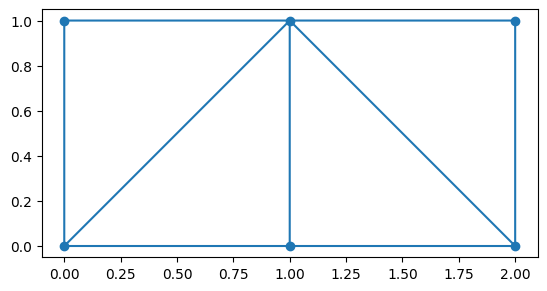

In [3]:
from scipy.spatial import Delaunay

tri = Delaunay(pts)     # samme punkter som over, men nå lar vi Delaunay velge trekantene selv

print(tri.simplices)    # samme type array som "triangles" vi definerte for hånd

plt.triplot(pts[:,0], pts[:,1], tri.simplices)   # tegner Delaunay sin triangulering
plt.scatter(pts[:,0], pts[:,1])                  # tegner punktene
plt.gca().set_aspect('equal')
plt.show()

`tri.simplices` er nøyaktig samme type array som `triangles`-arrayet vi selv definerte: en liste med indekser inn i `pts`, tre og tre, én rad per trekant (Delaunay kan velge en annen diagonal enn oss, men trekantene dekker fortsatt hele området). Vi kan derfor gjenbruke akkurat samme utregning som over -- vi pakker den inn i en funksjon, så slipper vi å skrive den på nytt hver gang:

In [4]:
def trekant_integrasjon(pts, triangles, f):
    p = pts[triangles[:,0]]        # første hjørne i hver trekant
    q = pts[triangles[:,1]]        # andre hjørne i hver trekant
    r = pts[triangles[:,2]]        # tredje hjørne i hver trekant
    n = len(p)                     # antall trekanter

    avg = 1/3 * (p + q + r)        # tyngdepunktet i hver trekant
    x = avg[:,0]
    y = avg[:,1]
    fverdier = f(x, y)             # funksjonsverdien i hvert tyngdepunkt

    u = q - p                      # vektorer som spenner ut trekanten
    v = r - p
    Muv = np.column_stack((u, v)).reshape(n, 2, 2)   # 2x2-matrise per trekant
    dA = np.abs(1/2 * np.linalg.det(Muv))            # areal av hver trekant

    return np.sum(dA * fverdier)   # summen tilnærmer integralet

def f(x, y):
    return x**2 + y

print("Delaunay med samme punkter:", trekant_integrasjon(pts, tri.simplices, f))

Delaunay med samme punkter: 3.5555555555555554


## Mange punkter -> mange trekanter -> bedre tilnærming

Nå kan vi lage et fint rutenett av punkter -- akkurat som vi har gjort med `np.linspace` og `np.meshgrid` tidligere -- og la `Delaunay` triangulere det for oss. Med mange trekanter forventer vi et resultat nær det eksakte svaret.

For $f(x,y)=x^2+y$ over $[0,2]\times[0,1]$ er det eksakte integralet
$$\int_0^2\!\int_0^1 (x^2+y)\, dy\, dx = \frac{11}{3} \approx 3.6667.$$

In [5]:
nx, ny = 60, 30
xvals = np.linspace(0, 2, nx)          # x-verdier over [0,2]
yvals = np.linspace(0, 1, ny)          # y-verdier over [0,1]
X, Y = np.meshgrid(xvals, yvals)       # rutenett av (x,y)-par

pts_fin = np.column_stack((X.ravel(), Y.ravel()))   # (nx*ny, 2) -- alle rutenett-punktene som (x,y)-par
tri_fin = Delaunay(pts_fin)                          # trianguler hele rutenettet automatisk

svar_fin = trekant_integrasjon(pts_fin, tri_fin.simplices, f)

print("Antall trekanter:", len(tri_fin.simplices))
print("Tilnærmet svar:", svar_fin)
print("Eksakt svar (11/3):", 11/3)

Antall trekanter: 3422
Tilnærmet svar: 3.666538989434709
Eksakt svar (11/3): 3.6666666666666665


### Oppgave (løses i forelesningen)

Bruk samme fremgangsmåte (rutenett med `np.linspace`/`np.meshgrid` + `Delaunay` + `trekant_integrasjon`) til å regne ut
$$\int_0^1\int_0^2 xy\, dy\, dx.$$

In [6]:
# Skriv koden her

## Alternativ: tilfeldige punkter med ekstra punkter på randen

Et rutenett er ikke den eneste måten å lage mange punkter på. Vi kan like gjerne bruke tilfeldige punkter -- akkurat som i Monte Carlo-notebooken. Det er likevel én ting vi må passe på: `Delaunay` triangulerer bare det konvekse hylsteret til punktene vi gir den, så strør vi ut rent tilfeldige punkter, er det ikke sikkert vi treffer helt ut i hjørnene og langs kantene av rektangelet -- trianguleringen kan da bli litt "avrundet" i kantene. Løsningen er å legge til noen punkter eksplisitt langs randen (og i hjørnene), i tillegg til de tilfeldige punktene i det indre.

Totalt antall punkter: 364


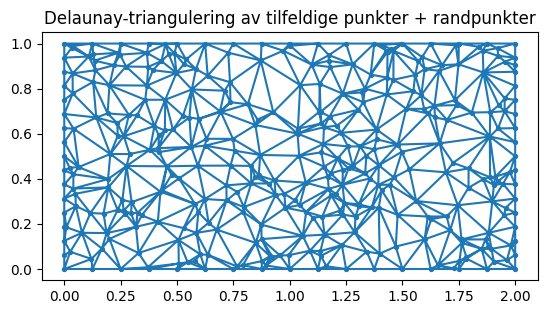

Antall trekanter: 662
Tilnærmet svar: 3.6653638751260433
Eksakt svar (11/3): 3.6666666666666665


In [7]:
np.random.seed(0)   # gjør at vi får de samme "tilfeldige" punktene hver gang vi kjører cellen

xmin, xmax = 0.0, 2.0   # samme rektangel som over: [0,2] x [0,1]
ymin, ymax = 0.0, 1.0

n_indre = 300   # antall tilfeldige punkter i det indre av rektangelet

# Tilfeldige punkter jevnt fordelt i rektangelet (samme idé som i Monte Carlo-notebooken)
indre_x = np.random.rand(n_indre) * (xmax - xmin) + xmin
indre_y = np.random.rand(n_indre) * (ymax - ymin) + ymin
indre = np.column_stack((indre_x, indre_y))   # (n_indre, 2) -- de indre punktene som (x,y)-par

# De fire hjørnene, lagt til eksplisitt slik at trianguleringen dekker HELE rektangelet
hjorner = np.array([
    [xmin, ymin],   # nede til venstre
    [xmax, ymin],   # nede til høyre
    [xmin, ymax],   # oppe til venstre
    [xmax, ymax],   # oppe til høyre
])

n_rand = 15   # antall ekstra punkter langs HVER av de fire kantene

# Punkter jevnt fordelt langs hver kant (hjørnene er allerede med, så de kuttes bort med [1:-1])
bunn    = np.column_stack((np.linspace(xmin, xmax, n_rand+2)[1:-1], np.full(n_rand, ymin)))   # y = ymin
topp    = np.column_stack((np.linspace(xmin, xmax, n_rand+2)[1:-1], np.full(n_rand, ymax)))   # y = ymax
venstre = np.column_stack((np.full(n_rand, xmin), np.linspace(ymin, ymax, n_rand+2)[1:-1]))   # x = xmin
hoyre   = np.column_stack((np.full(n_rand, xmax), np.linspace(ymin, ymax, n_rand+2)[1:-1]))   # x = xmax

# Setter sammen alt til én liste med punkter: indre (tilfeldige) + hjørner + randpunkter
pts_rand = np.vstack((indre, hjorner, bunn, topp, venstre, hoyre))
print("Totalt antall punkter:", len(pts_rand))

tri_rand = Delaunay(pts_rand)   # trianguler alle punktene

plt.triplot(pts_rand[:,0], pts_rand[:,1], tri_rand.simplices)
plt.scatter(pts_rand[:,0], pts_rand[:,1], s=8)   # s=8: litt mindre markører, siden vi har mange punkter
plt.gca().set_aspect('equal')
plt.title("Delaunay-triangulering av tilfeldige punkter + randpunkter")
plt.show()

svar_rand = trekant_integrasjon(pts_rand, tri_rand.simplices, f)   # samme funksjon som før

print("Antall trekanter:", len(tri_rand.simplices))
print("Tilnærmet svar:", svar_rand)
print("Eksakt svar (11/3):", 11/3)

Legg merke til at dette gir en tilnærming på samme nivå som rutenett-metoden over, bare med tilfeldig plasserte punkter i stedet for et jevnt rutenett -- randpunktene sørger for at vi likevel dekker hele rektangelet skikkelig.

### Oppgave (løses i forelesningen)

Bruk samme fremgangsmåte (tilfeldige indre punkter + randpunkter + `Delaunay` + `trekant_integrasjon`) til å regne ut
$$\int_0^\pi\int_0^1 \bigl(\sin(x)+y\bigr)\, dy\, dx.$$

In [8]:
# Skriv koden her

## Fra areal til volum: samme idé i 3 dimensjoner

Alt vi nettopp har gjort generaliserer direkte til én dimensjon høyere. I stedet for å dele et flatt område $D$ opp i trekanter, deler vi nå et romlig område $V$ opp i $N$ **tetraedre** (firesidete "klosser") med hjørner $p_i,q_i,r_i,s_i$, og bruker at
$$\iiint_V f(x,y,z)\, dV \approx \sum_{i=1}^N f(x_i,y_i,z_i)\, dV_i,$$
der $(x_i,y_i,z_i)=\tfrac14(p_i+q_i+r_i+s_i)$ er tyngdepunktet til tetraeder $i$, og volumet er
$$dV_i = \tfrac16\,\bigl|\det(u_i\ v_i\ w_i)\bigr|, \qquad u_i = q_i-p_i,\ \ v_i = r_i-p_i,\ \ w_i = s_i-p_i.$$

Legg merke til at dette er *nøyaktig* samme oppskrift som i 2D:
- tyngdepunktet er fortsatt gjennomsnittet av hjørnene (bare $\tfrac14$ av $4$ hjørner i stedet for $\tfrac13$ av $3$),
- volumet er fortsatt en determinant av kant-vektorer ut fra ett hjørne, bare med en $3\times 3$-matrise (tre kant-vektorer $u,v,w$ i rommet) i stedet for en $2\times 2$-matrise, og en faktor $\tfrac16$ i stedet for $\tfrac12$.


### Eksempel med håndplukkede tetraedre

Akkurat som vi lagde `pts` og `triangles` for hånd i 2D, lager vi nå `pts` med **tre** koordinater $(x,y,z)$ per punkt, og et array `tetrahedra` som sier hvilke **fire** punkter (indekser i `pts`) som utgjør hjørnene i hvert tetraeder.

Vi bruker samme rektangel-idé som over, bare med en ekstra dimensjon: boksen $[0,2]\times[0,1]\times[0,1]$, delt opp i to enhetskuber. Hver enhetskube kan deles i $6$ tetraedre (en standard måte å dele en kube i tetraedre på, der alle seks deler den samme romdiagonalen), så vi ender opp med $12$ tetraedre totalt. Vi integrerer samme type funksjon som før, nå med et ekstra ledd: $f(x,y,z)=x^2+y+z$.


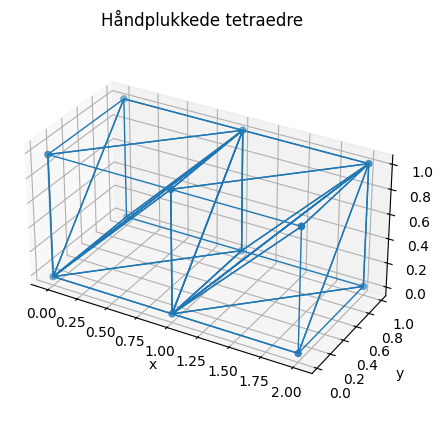

In [9]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  -- gjør 3D-plotting tilgjengelig

# Boksen [0,2]x[0,1]x[0,1], som 2 enhetskuber (x i {0,1} og x i {1,2})
pts = np.array([
    [0,0,0],[0,0,1],[0,1,0],[0,1,1],   # de 4 hjørnene med x=0
    [1,0,0],[1,0,1],[1,1,0],[1,1,1],   # de 4 hjørnene med x=1 (delt mellom de to kubene)
    [2,0,0],[2,0,1],[2,1,0],[2,1,1],   # de 4 hjørnene med x=2
], dtype=float)

# Hver rad = indekser (i pts) til de 4 hjørnene i ett tetraeder.
# De 6 første radene deler kuben [0,1]x[0,1]x[0,1], de 6 siste deler kuben [1,2]x[0,1]x[0,1].
tetrahedra = np.array([
    [0,4,6,7],[0,4,5,7],[0,2,6,7],[0,2,3,7],[0,1,5,7],[0,1,3,7],
    [4,8,10,11],[4,8,9,11],[4,6,10,11],[4,6,7,11],[4,5,9,11],[4,5,7,11],
])

def plot_tetrahedra(ax, pts, tetrahedra, **kwargs):
    '''3D-variant av plt.triplot: tegner de 6 kantene i hvert tetraeder.'''
    kanter = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]   # de 6 kantene mellom 4 hjørner
    for tet in tetrahedra:
        for i, j in kanter:
            p, q = pts[tet[i]], pts[tet[j]]
            ax.plot([p[0], q[0]], [p[1], q[1]], [p[2], q[2]], **kwargs)

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(projection='3d')
plot_tetrahedra(ax, pts, tetrahedra, color='C0', linewidth=1)   # tegner selve tetraedrene
ax.scatter(pts[:,0], pts[:,1], pts[:,2], color='C0')            # tegner punktene som markører
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_box_aspect((2,1,1))   # riktig skala mellom aksene, siden boksen er 2x1x1
ax.set_title('Håndplukkede tetraedre')
plt.show()


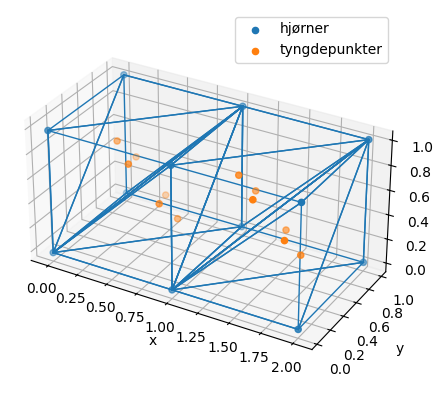

Tilnærmet svar: 4.583333333333333
Sum av volumene (skal være 2, siden boksen er 2x1x1): 2.0


In [10]:
p = pts[tetrahedra[:,0]]   # array med første hjørne i hvert tetraeder
q = pts[tetrahedra[:,1]]   # array med andre hjørne i hvert tetraeder
r = pts[tetrahedra[:,2]]   # array med tredje hjørne i hvert tetraeder
s = pts[tetrahedra[:,3]]   # array med fjerde hjørne i hvert tetraeder
n = len(p)                 # antall tetraedre

avg = 1/4 * (p + q + r + s)   # tyngdepunktet til hvert tetraeder
x = avg[:,0]
y = avg[:,1]
z = avg[:,2]
f = x**2 + y + z              # funksjonen f, evaluert i tyngdepunktene

# Plotting: tetraedrene, hjørnepunktene, og tyngdepunktene der vi evaluerer f
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(projection='3d')
plot_tetrahedra(ax, pts, tetrahedra, color='C0', linewidth=1)
ax.scatter(pts[:,0], pts[:,1], pts[:,2], color='C0', label='hjørner')
ax.scatter(x, y, z, color='C1', label='tyngdepunkter')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_box_aspect((2,1,1))
ax.legend()
plt.show()

# Vektorer som spenner ut hvert tetraeder, med utgangspunkt i hjørnet p
u = q - p
v = r - p
w = s - p

# Setter sammen u, v, w som kolonner i en 3x3-matrise, én per tetraeder
Muvw = np.column_stack((u, v, w)).reshape(n, 3, 3)   # (n,3,3) -- en array av 3x3-matriser
dV = np.abs(1/6 * np.linalg.det(Muvw))               # volumet til hvert tetraeder, via determinanten

svar = np.sum(dV * f)   # summerer f(tyngdepunkt) * dV over alle tetraedrene
print("Tilnærmet svar:", svar)
print("Sum av volumene (skal være 2, siden boksen er 2x1x1):", np.sum(dV))


## Automatisk tetraedrisering med `scipy.spatial.Delaunay`

Nøyaktig som i 2D blir det fort tungvint å plukke ut tetraedre for hånd når vi vil ha mange av dem. Det gode er at `Delaunay` fungerer *helt likt* i 3D: vi gir den rett og slett punkter med tre koordinater i stedet for to.

Den eneste forskjellen er at `tri.simplices` nå har **4** kolonner per rad i stedet for 3 -- hver rad er indeksene til de fire hjørnene i ett tetraeder, i stedet for de tre hjørnene i en trekant.

[[ 4  9 11  8]
 [ 4  5  9 11]
 [ 4 10 11  8]
 [ 4  7  6 11]
 [ 4  6 10 11]
 [ 4  7  5 11]
 [ 4  1  2  0]
 [ 4  5  3  1]
 [ 4  3  1  2]
 [ 4  6  3  2]
 [ 4  7  6  3]
 [ 4  7  5  3]]
Antall tetraedre: 12


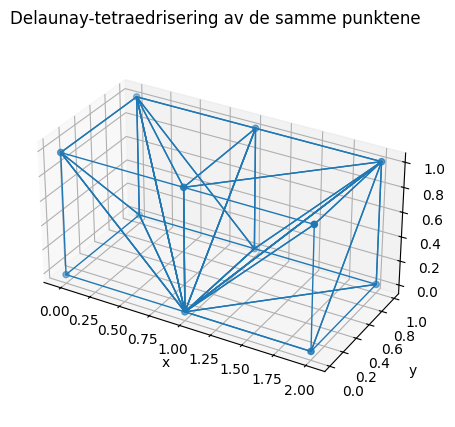

In [11]:
tri = Delaunay(pts)     # samme punkter som over, men nå lar vi Delaunay velge tetraedrene selv

print(tri.simplices)          # samme type array som "tetrahedra" vi definerte for hånd
print("Antall tetraedre:", len(tri.simplices))

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(projection='3d')
plot_tetrahedra(ax, pts, tri.simplices, color='C0', linewidth=1)   # tegner Delaunay sin tetraedrisering
ax.scatter(pts[:,0], pts[:,1], pts[:,2], color='C0')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_box_aspect((2,1,1))
ax.set_title('Delaunay-tetraedrisering av de samme punktene')
plt.show()


`tri.simplices` er nøyaktig samme type array som `tetrahedra`-arrayet vi selv definerte: en liste med indekser inn i `pts`, fire og fire, én rad per tetraeder. Sammenlign gjerne utskriften over med vår håndlagde `tetrahedra`: Delaunay kan velge en annen romdiagonal å dele hver kube langs enn den vi valgte (så de to listene med tetraedre er ikke nødvendigvis identiske, rad for rad) -- men begge er gyldige oppdelinger som dekker akkurat den samme boksen, så vi kan trygt gjenbruke akkurat samme utregning som over. Vi pakker den inn i en funksjon, helt analogt til `trekant_integrasjon`:

In [12]:
def tetraeder_integrasjon(pts, tetrahedra, f):
    p = pts[tetrahedra[:,0]]       # første hjørne i hvert tetraeder
    q = pts[tetrahedra[:,1]]       # andre hjørne i hvert tetraeder
    r = pts[tetrahedra[:,2]]       # tredje hjørne i hvert tetraeder
    s = pts[tetrahedra[:,3]]       # fjerde hjørne i hvert tetraeder
    n = len(p)                     # antall tetraedre

    avg = 1/4 * (p + q + r + s)    # tyngdepunktet i hvert tetraeder
    x = avg[:,0]
    y = avg[:,1]
    z = avg[:,2]
    fverdier = f(x, y, z)          # funksjonsverdien i hvert tyngdepunkt

    u = q - p                      # vektorer som spenner ut tetraederet
    v = r - p
    w = s - p
    Muvw = np.column_stack((u, v, w)).reshape(n, 3, 3)   # 3x3-matrise per tetraeder
    dV = np.abs(1/6 * np.linalg.det(Muvw))               # volum av hvert tetraeder

    return np.sum(dV * fverdier)   # summen tilnærmer integralet

def f(x, y, z):
    return x**2 + y + z

print("Delaunay med samme punkter:", tetraeder_integrasjon(pts, tri.simplices, f))


Delaunay med samme punkter: 4.583333333333333


## Mange punkter -> mange tetraedre -> bedre tilnærming

Akkurat som i 2D kan vi lage et fint rutenett av punkter med `np.linspace` og `np.meshgrid` -- nå bare i tre dimensjoner -- og la `Delaunay` tetraedrisere det for oss.

For $f(x,y,z)=x^2+y+z$ over $[0,2]\times[0,1]\times[0,1]$ er det eksakte integralet
$$\int_0^2\!\int_0^1\!\int_0^1 (x^2+y+z)\, dz\, dy\, dx = \frac{14}{3} \approx 4.6667.$$


In [13]:
nx, ny, nz = 25, 15, 15
xvals = np.linspace(0, 2, nx)              # x-verdier over [0,2]
yvals = np.linspace(0, 1, ny)              # y-verdier over [0,1]
zvals = np.linspace(0, 1, nz)              # z-verdier over [0,1]
X, Y, Z = np.meshgrid(xvals, yvals, zvals, indexing='ij')   # rutenett av (x,y,z)-punkter

pts_fin = np.column_stack((X.ravel(), Y.ravel(), Z.ravel()))   # (nx*ny*nz, 3) -- alle rutenett-punktene
tri_fin = Delaunay(pts_fin)                                     # tetraedriser hele rutenettet automatisk

svar_fin = tetraeder_integrasjon(pts_fin, tri_fin.simplices, f)

print("Antall tetraedre:", len(tri_fin.simplices))
print("Tilnærmet svar:", svar_fin)
print("Eksakt svar (14/3):", 14/3)


Antall tetraedre: 34060
Tilnærmet svar: 4.666087962962962
Eksakt svar (14/3): 4.666666666666667


### Oppgave (løses i forelesningen)

Bruk samme fremgangsmåte (rutenett med `np.linspace`/`np.meshgrid` + `Delaunay` + `tetraeder_integrasjon`) til å regne ut
$$\int_0^1\!\int_0^2\!\int_0^1 xyz\, dz\, dy\, dx.$$


In [14]:
# Skriv koden her


## Krumme områder: volumet av en sylinder

Metoden er ikke begrenset til bokser -- den fungerer like fint på krumme områder, akkurat som "tilfeldige punkter + randpunkter"-trikset i 2D. Forskjellen er at randen ("boundary") nå er en flate i rommet i stedet for en kurve i planet, så vi må plassere punkter på *hele* denne flaten:

- punkter jevnt fordelt langs sirkelen på **toppen** og **bunnen** av sylinderen,
- punkter på **sideflaten** (langs sirkler i flere høyder),
- og tilfeldige punkter i **det indre**, akkurat som i Monte Carlo-notebooken.

Volumet i seg selv er bare integralet av den konstante funksjonen $f=1$, så vi kan gjenbruke `tetraeder_integrasjon` helt uendret -- vi trenger ikke en egen "volumfunksjon". Vi tester på en sylinder med radius $R=2$ og høyde $H=4$, der det eksakte volumet er
$$V = \pi R^2 H = 16\pi \approx 50.265.$$


Totalt antall punkter: 4100
Antall tetraedre: 28708
Estimert volum:  50.2598
Eksakt volum:    50.2655
Relativ feil:    -0.011 %


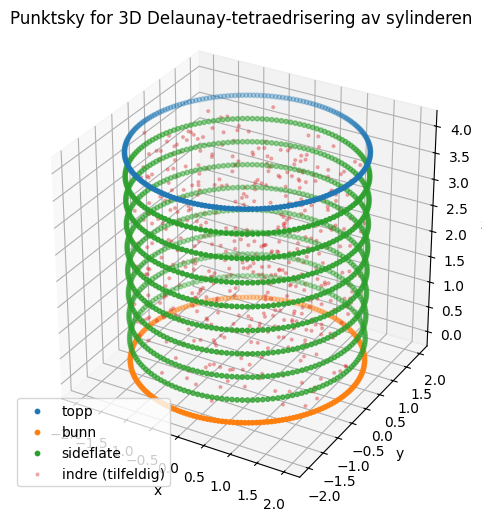

In [15]:
np.random.seed(7)   # gjør at vi får de samme "tilfeldige" punktene hver gang vi kjører cellen

R, H = 2.0, 4.0             # radius og høyde
V_eksakt = np.pi * R**2 * H  # eksakt volum

def sirkel_punkter(radius, z, n_theta):
    '''n_theta punkter jevnt fordelt langs sirkelen med gitt radius, i høyde z.'''
    theta = np.linspace(0, 2*np.pi, n_theta, endpoint=False)
    x = radius * np.cos(theta)
    y = radius * np.sin(theta)
    zz = np.full_like(x, z)
    return np.column_stack([x, y, zz])

def sideflate_punkter(radius, z_verdier, n_theta):
    '''Punkter på sideflaten: for hver høyde i z_verdier, n_theta punkter rundt sirkelen.'''
    ut = []
    for z in z_verdier:
        ut.append(sirkel_punkter(radius, z, n_theta))
    return np.vstack(ut)

def indre_punkter(radius, h, n):
    '''n tilfeldige punkter jevnt fordelt i DET INDRE av sylinderen.
    r = radius*sqrt(U) gir jevn tetthet over sirkelskiven (samme triks som i Monte Carlo-notebooken).'''
    theta = np.random.rand(n) * 2*np.pi
    r = radius * np.sqrt(np.random.rand(n))
    z = np.random.rand(n) * h
    return np.column_stack([r*np.cos(theta), r*np.sin(theta), z])

topp   = sirkel_punkter(R, H, n_theta=200)                    # punkter langs toppsirkelen
bunn   = sirkel_punkter(R, 0.0, n_theta=200)                  # punkter langs bunnsirkelen
side_z = np.linspace(0, H, 10)[1:-1]                          # noen mellomliggende høyder
side   = sideflate_punkter(R, side_z, n_theta=150)            # punkter på selve sideflaten
indre  = indre_punkter(R, H, n=2500)                          # tilfeldige punkter i det indre

pts_syl = np.vstack([topp, bunn, side, indre])
print("Totalt antall punkter:", len(pts_syl))

# 'QJ' gir Delaunay et lite puff for å unngå numeriske problemer med punkter på en glatt flate
tri_syl = Delaunay(pts_syl, qhull_options="QJ")
print("Antall tetraedre:", len(tri_syl.simplices))

def f_en(x, y, z):
    return np.ones_like(x)   # f = 1, siden vi bare vil regne ut volumet

V_est = tetraeder_integrasjon(pts_syl, tri_syl.simplices, f_en)

print(f"Estimert volum:  {V_est:.4f}")
print(f"Eksakt volum:    {V_eksakt:.4f}")
print(f"Relativ feil:    {100*(V_est - V_eksakt)/V_eksakt:.3f} %")

# ------------------------------------------------------------
# Visualiser punktskyen i 3D, fargelagt etter hvor punktene kommer fra
# ------------------------------------------------------------
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(projection='3d')
ax.scatter(*topp.T,  s=10, label='topp')
ax.scatter(*bunn.T,  s=10, label='bunn')
ax.scatter(*side.T,  s=10, label='sideflate')
ax.scatter(*indre[::5].T, s=4, alpha=0.3, label='indre (tilfeldig)')   # tegner bare hvert 5. indre punkt
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_box_aspect((1, 1, H/(2*R)))
ax.set_title('Punktsky for 3D Delaunay-tetraedrisering av sylinderen')
ax.legend()
plt.show()


Legg merke til at den relative feilen er svært liten, selv om sylinderen har en krum sideflate -- så lenge vi har nok punkter langs randen (topp, bunn og side) *og* i det indre, gir metoden en god tilnærming. Dette er akkurat samme byggeklosser som over: `tetraeder_integrasjon` bryr seg ikke om hvor punktene kommer fra, bare om at de tetraedriserer området riktig.

### Oppgave (løses i forelesningen)

Bruk samme fremgangsmåte til å regne ut volumet av en **kule** med radius $R$, og sammenlign med det eksakte volumet
$$V = \frac{4}{3}\pi R^3.$$

Tips: plasser tilfeldige punkter jevnt fordelt *inni* kulen (for eksempel med avvisningsmetoden fra Monte Carlo-notebooken, eller ved å skalere en tilfeldig retning med $R\sqrt[3]{U}$), og legg i tillegg noen punkter jevnt fordelt *på* kuleskallet, slik at Delaunay sitt konvekse hylster faktisk dekker hele kulen.


In [16]:
# Skriv koden her


## Oppsummering

1. Vi tilnærmer $\iint_D f\, dA$ ved å summere $f(\text{tyngdepunkt})\cdot dA$ over trekanter som dekker $D$.
2. Trekantene kan lages for hånd (praktisk for et lite eksempel), eller automatisk med `scipy.spatial.Delaunay` gitt en liste med punkter.
3. `tri.simplices` fungerer akkurat som vår håndlagde `triangles`-array, så samme formel gjenbrukes uendret.
4. Flere punkter gir flere, mindre trekanter -- og dermed en bedre tilnærming til det eksakte integralet.
5. Nøyaktig samme idé fungerer i 3D: trekanter blir til tetraedre, tyngdepunktet er fortsatt gjennomsnittet av hjørnene (nå $4$ i stedet for $3$), og arealet $\tfrac12|\det(u\ v)|$ blir til volumet $\tfrac16|\det(u\ v\ w)|$. `Delaunay` og `tri.simplices` fungerer helt likt, bare med én kolonne til per rad.
6. Å regne ut et *volum* er bare et spesialtilfelle: integrer den konstante funksjonen $f=1$ over området. Dette funker fint selv på krumme områder (som sylinderen over), så lenge vi passer på å legge punkter både på randen/flaten *og* i det indre.

Nå har dere det dere trenger for å fullføre den siste delen av oppgave 17 i Øving 1.
